# 1 · Relationships between variables

**Analytical question:** how do two variables move together — and how well does a
fitted model describe that relationship?

## Charts in this notebook

| Function | Level | Dataset | In one line |
|---|---|---|---|
| `scatterplot` | axes | penguins | raw points: the relationship between two numeric variables |
| `lineplot` | axes | fmri | a trend along an ordered axis, with a confidence band |
| `relplot` | figure | sp500 | scatter / line split into small multiples by a category |
| `regplot` | axes | california_housing | a scatter with a fitted regression line |
| `lmplot` | figure | tips | faceted regression across subsets |
| `residplot` | axes | california_housing | residuals of a fit — is the model adequate? |

**Method:** one minimal, idiomatic example per function. Each example ends by
saving a PNG to `images/`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from load_data import load_data

# House style for the whole notebook. Kept deliberately light: this project is
# about *which* chart to use, not fine visual polish.
sns.set_theme(style="whitegrid")

# Datasets used below. Built-ins come from seaborn; the two larger ones come
# from Kaggle via load_data() (downloaded once, then read from data/).
penguins = sns.load_dataset("penguins")
fmri = sns.load_dataset("fmri")
tips = sns.load_dataset("tips")
housing = load_data("california_housing")
sp500 = load_data("sp500")

## `scatterplot`

Axes-level. One point per row: the most direct view of how two numeric variables
relate. Extra variables map onto `hue`, `size`, `style` without changing the chart.

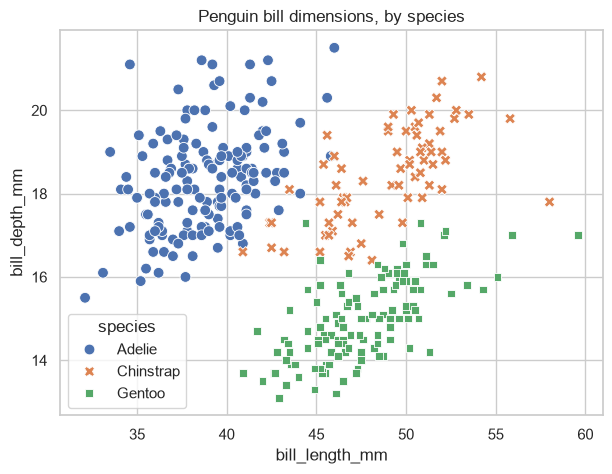

In [2]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=penguins,
    x="bill_length_mm", y="bill_depth_mm",
    hue="species", style="species",
    s=60, ax=ax,
)
ax.set_title("Penguin bill dimensions, by species")
fig.savefig("images/1_scatterplot.png", dpi=150, bbox_inches="tight")

**Best for**

- Two continuous variables, one row per observation — the first look at whether and how they relate.
- Layering in a third or fourth variable through `hue` / `size` / `style`.
- Spotting clusters, outliers and non-linear shape *before* modelling anything.
- **Not** when N is large and points pile up (overplotting) — switch to a 2-D `histplot`/`kdeplot`, or use `alpha` and sampling.

Note the trap this chart catches: pooled across species the cloud slopes *down*, but
within each species the relationship is *positive* (Simpson's paradox). `hue` is what
reveals it.

[`scatterplot` docs](https://seaborn.pydata.org/generated/seaborn.scatterplot.html)

## `lineplot`

Axes-level. Connects points along an ordered axis. When there are several
observations per x value it aggregates them (mean by default) and draws a
confidence band.

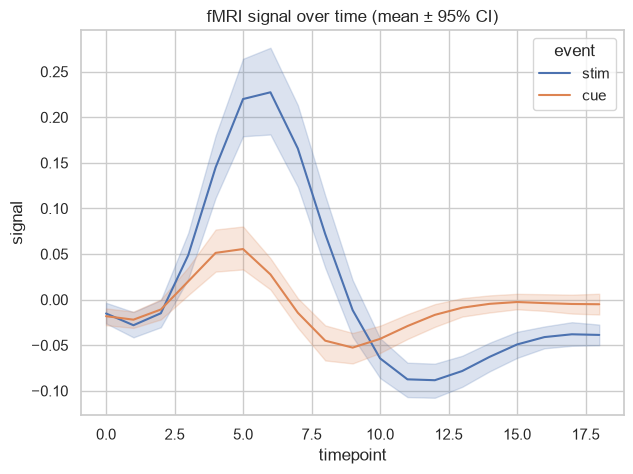

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.lineplot(
    data=fmri,
    x="timepoint", y="signal",
    hue="event", errorbar=("ci", 95),
    ax=ax,
)
ax.set_title("fMRI signal over time (mean ± 95% CI)")
fig.savefig("images/1_lineplot.png", dpi=150, bbox_inches="tight")

**Best for**

- A response measured along an *ordered* axis — time, dose, position — where connecting points implies continuity.
- Data with repeats per x: `lineplot` collapses them to an estimator and shades the uncertainty automatically (`errorbar=("ci", 95)`, `"se"`, `("pi", 95)`, …).
- Comparing a handful of series with `hue`.
- **Not** for unordered categories (the line invents a trend that isn't there), and not for dozens of overlapping series ("spaghetti") — facet instead.

[`lineplot` docs](https://seaborn.pydata.org/generated/seaborn.lineplot.html)

## `relplot`

Figure-level. The same scatter or line (`kind="scatter"` / `"line"`), but split
into a grid of small multiples with `row` / `col`. Returns a `FacetGrid`.

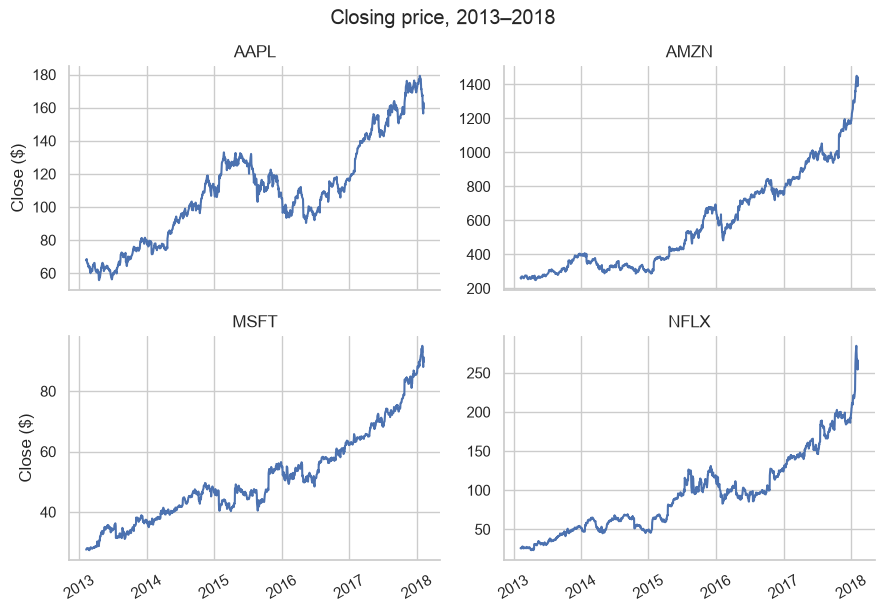

In [4]:
tickers = ["AAPL", "MSFT", "AMZN", "NFLX"]
subset = sp500[sp500["ticker"].isin(tickers)]

g = sns.relplot(
    data=subset,
    x="date", y="close", col="ticker",
    kind="line", col_wrap=2,
    height=3, aspect=1.5,
    facet_kws={"sharey": False},
)
g.set_titles("{col_name}")
g.set_axis_labels("", "Close ($)")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=30)
g.figure.suptitle("Closing price, 2013–2018", y=1.03)
g.savefig("images/1_relplot.png", dpi=150, bbox_inches="tight")

**Best for**

- Taking a `scatterplot` / `lineplot` and asking the same question across many subgroups, when one overlaid plot would be too busy.
- Figure-level conveniences: it owns the whole figure, wraps facets (`col_wrap`), and places one shared legend outside the axes.
- `facet_kws={"sharey": False}` when panels live on very different scales (as here).
- **Not** when you need to drop the plot onto a specific matplotlib `Axes` or combine it with other artists — use the axes-level `scatterplot` / `lineplot` for that.

[`relplot` docs](https://seaborn.pydata.org/generated/seaborn.relplot.html)

## `regplot`

Axes-level. A scatter plus an ordinary-least-squares line with a bootstrap
confidence band — a fit you can eyeball, in one call.

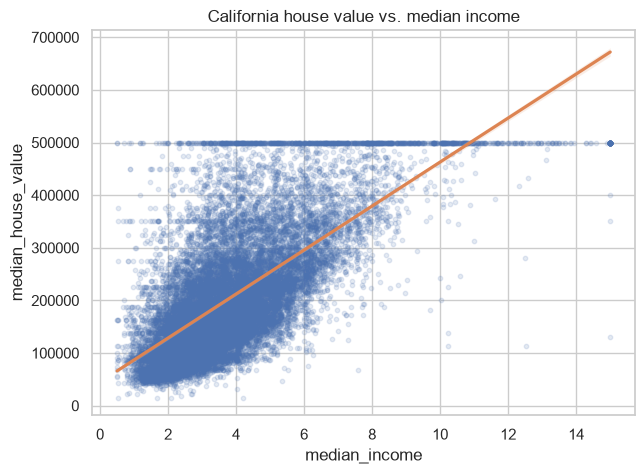

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(
    data=housing,
    x="median_income", y="median_house_value",
    scatter_kws={"alpha": 0.15, "s": 10},
    line_kws={"color": "C1"},
    ax=ax,
)
ax.set_title("California house value vs. median income")
fig.savefig("images/1_regplot.png", dpi=150, bbox_inches="tight")

**Best for**

- A fast look at direction and rough strength of a relationship before building a real model.
- Checking for curvature with `order=2` (polynomial) or `lowess=True` (local regression).
- **Not** a modelled fit: no coefficients, no R², no diagnostics. The flat strip along the top is the $500,001 cap baked into this dataset, and the way the spread widens with income is a warning the straight-line fit is too optimistic — which the next chart makes explicit.

[`regplot` docs](https://seaborn.pydata.org/generated/seaborn.regplot.html)

## `lmplot`

Figure-level. `regplot`'s fit, drawn on a `FacetGrid`: split by `col` / `row`
and/or `hue` to ask whether the relationship holds in every subgroup.

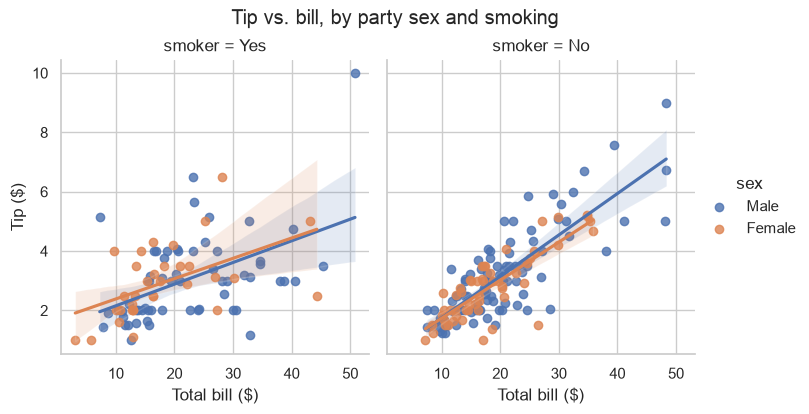

In [6]:
g = sns.lmplot(
    data=tips,
    x="total_bill", y="tip",
    col="smoker", hue="sex",
    height=4, aspect=0.9,
)
g.set_axis_labels("Total bill ($)", "Tip ($)")
g.figure.suptitle("Tip vs. bill, by party sex and smoking", y=1.03)
g.savefig("images/1_lmplot.png", dpi=150, bbox_inches="tight")

**Best for**

- "Does this trend look the same for everyone?" — one fitted line per facet / colour, on shared axes for easy comparison.
- Anything `regplot` accepts (`order`, `logistic`, `lowess`, `robust`) carried across the grid.
- **Not** for a single panel (use `regplot`) or for scatters you don't want a regression on (use `relplot`).

[`lmplot` docs](https://seaborn.pydata.org/generated/seaborn.lmplot.html)

## `residplot`

Axes-level. Fits a line, then plots the *residuals* against the predictor. If the
linear model fits well, this is a shapeless band around zero.

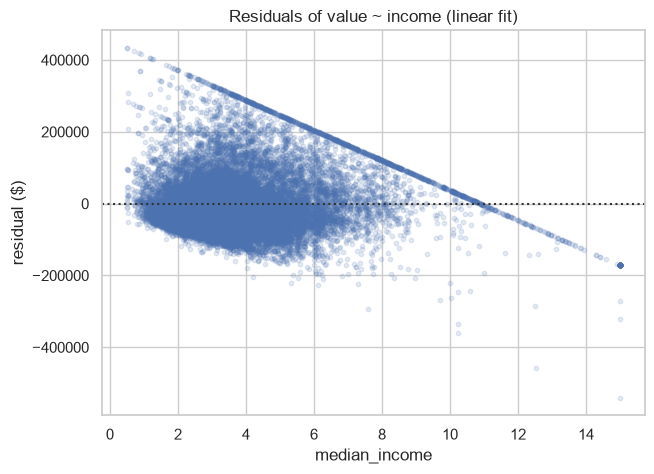

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.residplot(
    data=housing,
    x="median_income", y="median_house_value",
    scatter_kws={"alpha": 0.15, "s": 10},
    ax=ax,
)
ax.set_title("Residuals of value ~ income (linear fit)")
ax.set_ylabel("residual ($)")
fig.savefig("images/1_residplot.png", dpi=150, bbox_inches="tight")

**Best for**

- Diagnosing a linear fit: random scatter around zero ⇒ a straight line is enough.
- Seeing what the fit *missed* — a smile / frown means curvature; a fan or funnel means the variance grows (heteroscedasticity).
- Here the residuals bow below zero in the middle (curvature) and fan out as income rises (heteroscedasticity): a straight line is the wrong shape. The crisp diagonal edge along the top is the $500,001 cap again — for those rows the residual is forced to shrink as income grows.
- **Not** an outlier flag or a normality test — it only shows structure left over from the mean fit. Add `lowess=True` to draw the trend through the residuals.

[`residplot` docs](https://seaborn.pydata.org/generated/seaborn.residplot.html)